# Customer Behavior Prediction using Machine Learning

##  Student Details

* **Name:** G Pavani
* **Enrollment No:** 24CS003379
* **Course:** B.Tech CSE (AIML)
* **Project Title:** Customer Behavior Prediction
* **Subject:** Machine Learning (ML D53)

---

##  Project Overview

* This project focuses on analyzing customer behavior using an e-commerce dataset.
* The goal is to predict customer satisfaction based on purchase and delivery details.
* Machine learning models are used to identify patterns in customer data.
* The best model is selected based on performance comparison.


##  Workflow

* Load all required datasets
* Merge datasets using common columns (order_id, customer_id, product_id)
* Perform data cleaning (remove missing values and duplicates)
* Convert date columns into proper format
* Create new features (total price, delivery time)
* Define target variable (customer satisfaction based on review score)
* Select important features for model training
* Split data into training and testing sets
* Apply machine learning models (Logistic Regression, KNN, Random Forest)
* Evaluate models using accuracy score
* Compare results and select the best model


##  Dataset Description
* The dataset used is the Olist Brazilian E-commerce dataset from Kaggle.
* It consists of 9 CSV files containing real-world e-commerce data.

### Datasets Included:

* olist_customers_dataset – customer information
* olist_orders_dataset – order details
* olist_order_items_dataset – product details in each order
* olist_order_payments_dataset – payment information
* olist_order_reviews_dataset – customer reviews and ratings
* olist_products_dataset – product details
* olist_sellers_dataset – seller information
* olist_geolocation_dataset – location data
* product_category_name_translation – category name translation
* These datasets are connected using common keys like order_id and customer_id.
* The combined data helps analyze customer behavior and satisfaction.



##  Import Libraries

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries Loaded Successfully ")

Libraries Loaded Successfully 


## Load Datasets

In [6]:
customers = pd.read_csv("olist_customers_dataset.csv")
geolocation = pd.read_csv("olist_geolocation_dataset.csv")
order_items = pd.read_csv("olist_order_items_dataset.csv")
payments = pd.read_csv("olist_order_payments_dataset.csv")
reviews = pd.read_csv("olist_order_reviews_dataset.csv")
orders = pd.read_csv("olist_orders_dataset.csv")
products = pd.read_csv("olist_products_dataset.csv")
sellers = pd.read_csv("olist_sellers_dataset.csv")
category = pd.read_csv("product_category_name_translation.csv")
print("All datasets loaded successfully ")


All datasets loaded successfully 


##  Data Understanding

In [7]:
print("Customers:", customers.shape)
print("Orders:", orders.shape)
print("Order Items:", order_items.shape)
print("Payments:", payments.shape)
print("Reviews:", reviews.shape)

Customers: (99441, 5)
Orders: (99441, 8)
Order Items: (112650, 7)
Payments: (103886, 5)
Reviews: (99224, 7)


##  Data Merging

In [8]:
data = pd.merge(orders, customers, on="customer_id")
data = pd.merge(data, order_items, on="order_id")
data = pd.merge(data, payments, on="order_id")
data = pd.merge(data, reviews, on="order_id")
data = pd.merge(data, products, on="product_id")
data = pd.merge(data, category, on="product_category_name", how="left")

print("Merged dataset shape:", data.shape)

Merged dataset shape: (117329, 37)


## Data Cleaning

In [12]:
# Separate numeric and categorical columns

num_cols = data.select_dtypes(include=['int64', 'float64']).columns
cat_cols = data.select_dtypes(include=['object', 'string']).columns

# Fill numeric columns with 0
data[num_cols] = data[num_cols].fillna(0)

# Fill categorical (string) columns with 'Unknown'
data[cat_cols] = data[cat_cols].fillna('Unknown')

print("Missing values handled correctly ")

Missing values handled correctly 


## Feature Engineering

In [16]:
# Convert date columns
data['order_purchase_timestamp'] = pd.to_datetime(
    data['order_purchase_timestamp'], errors='coerce'
)

data['order_delivered_customer_date'] = pd.to_datetime(
    data['order_delivered_customer_date'], errors='coerce'
)

# Total price
data['total_price'] = data['price'] + data['freight_value']

# Delivery time
data['delivery_time'] = (
    data['order_delivered_customer_date'] - data['order_purchase_timestamp']
).dt.days

data['delivery_time'] = data['delivery_time'].fillna(0)

# Target
data['target'] = data['review_score'].apply(lambda x: 1 if x >= 4 else 0)

print("Feature Engineering Done ")

Feature Engineering Done 


##  Feature Selection

In [18]:
features = ['total_price', 'freight_value', 'payment_value', 'delivery_time']

X = data[features]
y = data['target']

print("Features Selected ")

Features Selected 


## Train-Test Split

In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train-Test Split Done ")

Train-Test Split Done 


##  Data Scaling

In [20]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Scaling Done ")

Scaling Done 


##  Logistic Regression Model

In [21]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()
lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

##  K-Nearest Neighbors (KNN)

In [22]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

knn_pred = knn.predict(X_test)

##  Random Forest Model

In [26]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

## Model Evaluation

In [27]:
from sklearn.metrics import accuracy_score

print("Logistic Regression:", accuracy_score(y_test, lr_pred))
print("KNN:", accuracy_score(y_test, knn_pred))
print("Random Forest:", accuracy_score(y_test, rf_pred))

Logistic Regression: 0.7674081650046877
KNN: 0.7847097928918435
Random Forest: 0.8167987726924061


## Results

In [28]:
from sklearn.metrics import confusion_matrix

print(confusion_matrix(y_test, rf_pred))

[[ 2802  3067]
 [ 1232 16365]]


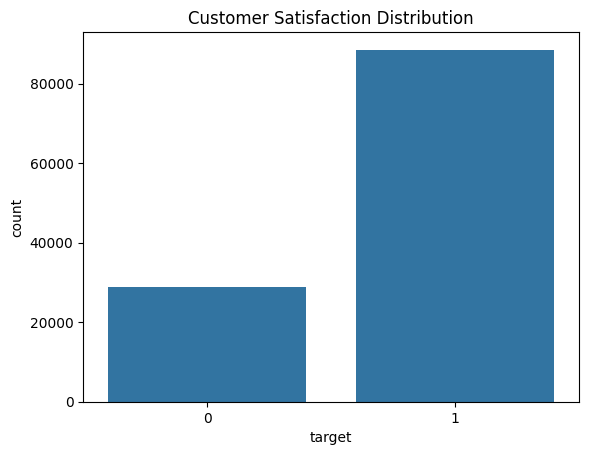

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='target', data=data)
plt.title("Customer Satisfaction Distribution")
plt.show()

##  Conclusion

- Customer behavior prediction was successfully performed using machine learning.
- The dataset was processed, cleaned, and analyzed effectively.
- Random Forest provided the best performance.
- The model can help businesses improve customer satisfaction and decision-making.

##  Project Description

* This project focuses on analyzing customer behavior using an e-commerce dataset.
* The dataset consists of multiple files including customers, orders, products, payments, and reviews.
* All datasets were merged using common keys like order_id and customer_id.
* Data cleaning was performed to handle missing values and duplicates.
* New features such as total price and delivery time were created.
* Customer satisfaction was defined as the target variable based on review scores.
* Machine learning models like Logistic Regression, KNN, and Random Forest were applied.
* The models were evaluated using accuracy score.
* Random Forest performed best among all models.
* The project helps businesses understand customer behavior and improve services.
